# Phase 3 — Multi-Agent DQN Coordination

This notebook implements the Phase 3 shuttle task with a **shared Deep Q-Network (DQN)** trained **from scratch** entirely within a self-contained notebook environment.

### Assignment constraints implemented

- 5×5 grid.
- Exactly four agents.
- Four actions only: **North, South, West, East** (`Enum`); there is no `wait`.
- Agents act **sequentially in a random order**.
- Continuous shuttle behaviour: **A → B → A → ...**.
- Head-on collisions only matter between agents travelling in opposite directions.
- Collisions at A and B are ignored.
- Agents may attempt to move into walls; the position is clamped to the grid.
- No pretrained model, checkpoint, imitation learning, behaviour cloning, or RL library.
- PyTorch is used only to implement the neural-network Q-function.
- The only purchased option is the **opposite-direction neighbouring-agent sensor** (`C = 3`).

## Design decision and evaluation interpretation

The task text contains one wording conflict: it says the final delivery starts at B, but immediately defines the measured route as **starting at A, moving to B, and returning to A**. This notebook follows the explicit A→B→A step definition.

During final evaluation, all four agents start at A carrying an item. A cycle is successful when an agent delivers at B and returns to A within 25 of its own action opportunities without a collision.

### Why one paid sensor?

The default observation does not reveal other agents, yet the task asks for collision avoidance. The selected `Sensors (Opposite agents)` option adds four neighbouring-cell bits (N/S/W/E) indicating nearby opposite-direction traffic. No fixed B, central clock, staged training, or predefined training configurations are used.

The two relative-target features used by the DQN are computed only from information the agent already observes (its position, A, B, and carrying status), so they do not add a sensor cost.

## DQN architecture

Each agent uses the same network:

`13 input features → 64 ReLU → 64 ReLU → 4 Q-values`

The 13 inputs are:
- own `(row, column)` — 2
- A `(row, column)` — 2
- B `(row, column)` — 2
- carrying bit — 1
- relative target `(Δrow, Δcolumn)` — 2
- opposite-direction neighbour sensor bits `(N, S, W, E)` — 4

Training uses:
- ε-greedy exploration,
- experience replay,
- an online network,
- a frozen target network,
- mean-squared TD loss,
- periodic target synchronization.

## Hyperparameters

| Setting | Value |
|---|---:|
| learning rate | `1e-3` |
| discount factor γ | `0.95` |
| ε start / minimum | `1.0 / 0.03` |
| ε decay fraction | `0.20` |
| replay capacity | `50,000` |
| batch size | `64` |
| warm-up transitions | `512` |
| target sync | `500` optimizer updates |
| network | `13 → 64 → 64 → 4` |
| training agent steps | `80,000` |
| purchased cost | `C = 3` |
| seed | `1` |

## 1. Imports and Setup

In [1]:
import json
import random
import time
import unittest
from dataclasses import asdict, dataclass, field, replace
from enum import IntEnum
from pathlib import Path
from typing import TypeAlias, cast

import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray
import torch
from torch import nn

## 2. Constants, Enums, and Types

In [2]:
GRID_SIZE = 5
AGENT_COUNT = 4
ACTION_COUNT = 4
BASE_FEATURE_COUNT = 7
RELATIVE_FEATURE_COUNT = 2
SENSOR_FEATURE_COUNT = 4
OBSERVATION_SIZE = 13
STEP_REWARD = -1.0
PICKUP_BONUS = 10.0
DELIVERY_BONUS = 40.0
COLLISION_REWARD = -50.0
TRAINING_STEP_BUDGET = 1_500_000
TRAINING_COLLISION_BUDGET = 4_000
TRAINING_TIME_BUDGET = 600.0
PERFORMANCE_STEP_LIMIT = 25
SCALING_COEFFICIENT = 33.0 / 200.0
OPPOSITE_SENSOR_COST = 3
DEFAULT_HIDDEN_SIZE = 64
CPU_DEVICE = "cpu"

SUCCESS_RATE_TOP = 0.95
SUCCESS_RATE_MID = 0.85
COLLISION_TOP = 500
COLLISION_MID = 1_000


class Direction(IntEnum):
    NORTH = 0
    SOUTH = 1
    WEST = 2
    EAST = 3


Position: TypeAlias = tuple[int, int]
FloatArray: TypeAlias = NDArray[np.float32]
IntArray: TypeAlias = NDArray[np.int64]


@dataclass(frozen=True)
class AgentState:
    position: Position
    has_item: bool
    deliveries: int = 0


AgentTuple: TypeAlias = tuple[
    AgentState, AgentState, AgentState, AgentState
]


@dataclass(frozen=True)
class WorldState:
    agents: AgentTuple
    pickup: Position
    dropoff: Position


@dataclass(frozen=True)
class StepResult:
    world: WorldState
    reward: float
    has_collision: bool


@dataclass(frozen=True)
class Transition:
    state: FloatArray
    action: int
    reward: float
    next_state: FloatArray


@dataclass(frozen=True)
class ReplayBatch:
    states: FloatArray
    actions: IntArray
    rewards: FloatArray
    next_states: FloatArray

## 3. Metrics and Configurations

In [3]:
@dataclass
class TrainingProgress:
    steps: int = 0
    collisions: int = 0
    rounds: int = 0
    round_reward: float = 0.0
    rewards: list[float] = field(default_factory=list)
    losses: list[float] = field(default_factory=list)


@dataclass(frozen=True)
class TrainingMetrics:
    agent_steps: int
    collisions: int
    wall_seconds: float
    rewards: tuple[float, ...]
    losses: tuple[float, ...]


@dataclass
class CycleTracker:
    delivered: list[bool] = field(
        default_factory=lambda: [False] * AGENT_COUNT
    )
    completed: list[bool] = field(
        default_factory=lambda: [False] * AGENT_COUNT
    )
    collided: list[bool] = field(
        default_factory=lambda: [False] * AGENT_COUNT
    )
    collisions: int = 0


@dataclass(frozen=True)
class EvaluationMetrics:
    agent_success_rate: float
    scenario_success_rate: float
    collisions: int
    scenarios: int
    agent_trials: int


@dataclass(frozen=True)
class ScoreResult:
    success_points: int
    collision_points: int
    performance_points: int
    cost: int
    scale: float


@dataclass(frozen=True)
class LearningConfig:
    learning_rate: float = 1e-3
    gamma: float = 0.95
    epsilon_start: float = 1.0
    epsilon_min: float = 0.03
    epsilon_decay_fraction: float = 0.20
    replay_capacity: int = 50_000
    batch_size: int = 64
    warmup_steps: int = 512
    target_sync_updates: int = 500
    gradient_clip: float = 10.0
    hidden_size: int = 64


@dataclass(frozen=True)
class TrainingConfig:
    agent_steps: int = 80_000
    reset_interval_steps: int = 800
    seed: int = 1
    cost: int = OPPOSITE_SENSOR_COST


@dataclass(frozen=True)
class EvaluationConfig:
    max_actions: int = PERFORMANCE_STEP_LIMIT
    repeats: int = 3
    seed: int = 99

## 4. Geometry, World, Features, and Environment

In [4]:
MOVE_DELTAS: dict[Direction, Position] = {
    Direction.NORTH: (-1, 0),
    Direction.SOUTH: (1, 0),
    Direction.WEST: (0, -1),
    Direction.EAST: (0, 1),
}


def clamp(value: int) -> int:
    return max(0, min(GRID_SIZE - 1, value))


def move(position: Position, action: Direction) -> Position:
    delta = MOVE_DELTAS[action]
    row = clamp(position[0] + delta[0])
    column = clamp(position[1] + delta[1])
    return row, column


def get_cells() -> tuple[Position, ...]:
    values = range(GRID_SIZE)
    return tuple((row, col) for row in values for col in values)


PICKUP: Position = (0, 0)


def sample_dropoff(rng: np.random.Generator) -> Position:
    cells = tuple(cell for cell in get_cells() if cell != PICKUP)
    return cells[int(rng.integers(len(cells)))]


def sample_agent(rng: np.random.Generator) -> AgentState:
    row = int(rng.integers(GRID_SIZE))
    column = int(rng.integers(GRID_SIZE))
    has_item = bool(rng.integers(2))
    return AgentState((row, column), has_item)


def sample_agents(rng: np.random.Generator) -> AgentTuple:
    values = tuple(sample_agent(rng) for _ in range(AGENT_COUNT))
    first, second, third, fourth = values
    return first, second, third, fourth


def reset_world(rng: np.random.Generator) -> WorldState:
    agents = sample_agents(rng)
    dropoff = sample_dropoff(rng)
    return WorldState(agents, PICKUP, dropoff)


def create_evaluation_world(dropoff: Position) -> WorldState:
    agent = AgentState(PICKUP, True)
    agents: AgentTuple = (agent, agent, agent, agent)
    return WorldState(agents, PICKUP, dropoff)


def normalize(value: int) -> float:
    return value / float(GRID_SIZE - 1)


def get_target(agent: AgentState, world: WorldState) -> Position:
    if agent.has_item:
        return world.dropoff
    return world.pickup


def is_opposite(other: AgentState, agent: AgentState) -> bool:
    return other.has_item != agent.has_item


def is_opposite_at(other: AgentState, agent: AgentState,
                   position: Position) -> bool:
    checks = (other.position == position, is_opposite(other, agent))
    return all(checks)


def has_opposite_at(world: WorldState, index: int,
                    position: Position) -> bool:
    agent = world.agents[index]
    flags = tuple(is_opposite_at(other, agent, position)
                  for other in world.agents)
    return any(flags)


def get_neighbor_positions(position: Position) -> tuple[Position, ...]:
    return tuple((position[0] + delta[0], position[1] + delta[1])
                 for delta in MOVE_DELTAS.values())


def get_sensor_bits(world: WorldState, index: int) -> tuple[float, ...]:
    position = world.agents[index].position
    neighbors = get_neighbor_positions(position)
    return tuple(float(has_opposite_at(world, index, cell))
                 for cell in neighbors)


def get_base_features(world: WorldState, index: int) -> tuple[float, ...]:
    agent = world.agents[index]
    values = (*agent.position, *world.pickup, *world.dropoff)
    scaled = tuple(normalize(value) for value in values)
    return (*scaled, float(agent.has_item))


def get_relative_features(world: WorldState,
                          index: int) -> tuple[float, float]:
    agent = world.agents[index]
    target = get_target(agent, world)
    scale = float(GRID_SIZE - 1)
    row = (target[0] - agent.position[0]) / scale
    return row, (target[1] - agent.position[1]) / scale


def encode_observation(world: WorldState, index: int) -> FloatArray:
    base = get_base_features(world, index)
    relative = get_relative_features(world, index)
    sensors = get_sensor_bits(world, index)
    values = (*base, *relative, *sensors)
    return np.asarray(values, dtype=np.float32)


def is_pickup(agent: AgentState, world: WorldState) -> bool:
    checks = (agent.position == world.pickup, agent.has_item is False)
    return all(checks)


def is_delivery(agent: AgentState, world: WorldState) -> bool:
    checks = (agent.position == world.dropoff, agent.has_item)
    return all(checks)


def get_mission_bonus(agent: AgentState, world: WorldState) -> float:
    if is_pickup(agent, world):
        return PICKUP_BONUS
    if is_delivery(agent, world):
        return DELIVERY_BONUS
    return 0.0


def apply_mission(agent: AgentState, world: WorldState) -> AgentState:
    if is_pickup(agent, world):
        return replace(agent, has_item=True)
    if is_delivery(agent, world):
        return AgentState(agent.position, False, agent.deliveries + 1)
    return agent


def replace_agent(world: WorldState, index: int,
                  agent: AgentState) -> WorldState:
    values = list(world.agents)
    values[index] = agent
    agents = cast(AgentTuple, tuple(values))
    return WorldState(agents, world.pickup, world.dropoff)


def is_endpoint(agent: AgentState, world: WorldState) -> bool:
    return agent.position in (world.pickup, world.dropoff)


def get_conflicts(world: WorldState, index: int,
                  travel_mode: bool) -> tuple[bool, ...]:
    current = world.agents[index]
    return tuple(other.position == current.position
                 and other.has_item != travel_mode
                 for other in world.agents)


def detect_collision(world: WorldState, index: int,
                     travel_mode: bool) -> bool:
    is_safe_endpoint = is_endpoint(world.agents[index], world)
    if is_safe_endpoint:
        return False
    return any(get_conflicts(world, index, travel_mode))


def get_reward(moved: AgentState, world: WorldState,
               has_collision: bool) -> float:
    if has_collision:
        return COLLISION_REWARD
    return STEP_REWARD + get_mission_bonus(moved, world)


def move_agent(agent: AgentState, action: Direction) -> AgentState:
    return replace(agent, position=move(agent.position, action))


def step_agent(world: WorldState, index: int,
               action: Direction) -> StepResult:
    before = world.agents[index]
    moved = move_agent(before, action)
    updated = replace_agent(world, index, apply_mission(moved, world))
    has_collision = detect_collision(updated, index, before.has_item)
    reward = get_reward(moved, world, has_collision)
    return StepResult(updated, reward, has_collision)

## 5. DQN Architecture, Replay, Policy, and Learner

In [5]:
def create_layers(hidden_size: int) -> nn.Sequential:
    return nn.Sequential(
        nn.Linear(OBSERVATION_SIZE, hidden_size), nn.ReLU(),
        nn.Linear(hidden_size, hidden_size), nn.ReLU(),
        nn.Linear(hidden_size, ACTION_COUNT),
    )


class DqnNetwork(nn.Module):
    def __init__(self, hidden_size: int) -> None:
        super().__init__()
        self.layers = create_layers(hidden_size)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.layers(inputs)


class ReplayBuffer:
    def __init__(self, capacity: int) -> None:
        self.states = np.zeros((capacity, OBSERVATION_SIZE), np.float32)
        self.actions = np.zeros(capacity, np.int64)
        self.rewards = np.zeros(capacity, np.float32)
        self.next_states = np.zeros((capacity, OBSERVATION_SIZE), np.float32)
        self.capacity, self.size, self.position = capacity, 0, 0

    def add(self, item: Transition) -> None:
        position = self.position
        self.states[position], self.actions[position] = item.state, item.action
        self.rewards[position] = item.reward
        self.next_states[position] = item.next_state
        self.position = (position + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, size: int, rng: np.random.Generator) -> ReplayBatch:
        indices = rng.integers(0, self.size, size=size)
        states, actions = self.states[indices], self.actions[indices]
        rewards = self.rewards[indices]
        next_states = self.next_states[indices]
        return ReplayBatch(states, actions, rewards, next_states)


def calculate_epsilon(step: int, total_steps: int,
                      config: LearningConfig) -> float:
    horizon = max(1, int(total_steps * config.epsilon_decay_fraction))
    fraction = min(1.0, step / horizon)
    span = config.epsilon_start - config.epsilon_min
    return max(config.epsilon_min,
               config.epsilon_start - span * fraction)


def get_greedy_action(network: DqnNetwork, state: FloatArray) -> int:
    tensor = torch.from_numpy(state).unsqueeze(0)
    with torch.no_grad():
        value = network(tensor).argmax(dim=1).item()
    return int(value)


def create_networks(config: LearningConfig) -> tuple[DqnNetwork, DqnNetwork]:
    online = DqnNetwork(config.hidden_size)
    target = DqnNetwork(config.hidden_size)
    target.load_state_dict(online.state_dict())
    return online, target


def create_optimizer(network: DqnNetwork,
                     config: LearningConfig) -> torch.optim.Optimizer:
    return torch.optim.Adam(network.parameters(), lr=config.learning_rate)


class DqnLearner:
    def __init__(self, config: LearningConfig,
                 rng: np.random.Generator) -> None:
        self.config, self.rng = config, rng
        self.online, self.target = create_networks(config)
        self.optimizer = create_optimizer(self.online, config)
        self.replay = ReplayBuffer(config.replay_capacity)
        self.updates = 0

    def has_warmup(self) -> bool:
        return self.replay.size >= self.config.warmup_steps

    def select_action(self, state: FloatArray, epsilon: float) -> int:
        is_exploring = self.rng.random() < epsilon
        if is_exploring:
            return int(self.rng.integers(ACTION_COUNT))
        return self.get_greedy_action(state)

    def get_greedy_action(self, state: FloatArray) -> int:
        tensor = torch.from_numpy(state).unsqueeze(0)
        with torch.no_grad():
            value = self.online(tensor).argmax(dim=1).item()
        return int(value)

    def get_current_values(self, batch: ReplayBatch) -> torch.Tensor:
        states = torch.from_numpy(batch.states)
        actions = torch.from_numpy(batch.actions)
        values = self.online(states).gather(1, actions[:, None])
        return values.squeeze(1)

    def get_targets(self, batch: ReplayBatch) -> torch.Tensor:
        rewards = torch.from_numpy(batch.rewards)
        next_states = torch.from_numpy(batch.next_states)
        with torch.no_grad():
            future = self.target(next_states).max(dim=1).values
        return rewards + self.config.gamma * future

    def calculate_loss(self, batch: ReplayBatch) -> torch.Tensor:
        current = self.get_current_values(batch)
        targets = self.get_targets(batch)
        return nn.functional.mse_loss(current, targets)

    def should_sync(self) -> bool:
        is_updated = self.updates > 0
        is_due = self.updates % self.config.target_sync_updates == 0
        return all((is_updated, is_due))

    def sync_target(self) -> None:
        self.target.load_state_dict(self.online.state_dict())

    def apply_gradient(self, loss: torch.Tensor) -> None:
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online.parameters(),
                                 self.config.gradient_clip)
        self.optimizer.step()

    def learn(self) -> float:
        batch = self.replay.sample(self.config.batch_size, self.rng)
        loss = self.calculate_loss(batch)
        self.apply_gradient(loss)
        self.updates += 1
        return float(loss.item())

## 6. Training, Evaluation, Scoring, and Plots

In [6]:
def set_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(1)


class Trainer:
    def __init__(self, learner: DqnLearner,
                 config: TrainingConfig) -> None:
        self.learner, self.config = learner, config
        self.progress = TrainingProgress()
        self.world = reset_world(learner.rng)

    def has_budget(self, seconds: float) -> bool:
        checks = (self.progress.steps < self.config.agent_steps,
                  self.progress.collisions < TRAINING_COLLISION_BUDGET,
                  seconds < TRAINING_TIME_BUDGET)
        return all(checks)

    def get_epsilon(self) -> float:
        return calculate_epsilon(self.progress.steps,
                                 self.config.agent_steps,
                                 self.learner.config)

    def apply_action(self, index: int, action: int,
                     state: FloatArray) -> tuple[float, bool]:
        result = step_agent(self.world, index, Direction(action))
        next_state = encode_observation(result.world, index)
        self.learner.replay.add(Transition(state, action,
                                           result.reward, next_state))
        self.world = result.world
        return result.reward, result.has_collision

    def train_agent(self, index: int) -> None:
        state = encode_observation(self.world, index)
        action = self.learner.select_action(state, self.get_epsilon())
        reward, has_collision = self.apply_action(index, action, state)
        self.progress.round_reward += reward
        self.progress.collisions += int(has_collision)
        self.progress.steps += 1

    def train_round(self) -> None:
        self.progress.round_reward = 0.0
        for value in self.learner.rng.permutation(AGENT_COUNT):
            self.train_agent(int(value))
        self.progress.rewards.append(self.progress.round_reward)
        self.progress.rounds += 1

    def update_learner(self) -> None:
        if self.learner.has_warmup():
            self.progress.losses.append(self.learner.learn())
        if self.learner.should_sync():
            self.learner.sync_target()

    def maybe_reset(self) -> None:
        remainder = self.progress.steps % self.config.reset_interval_steps
        is_reset_due = remainder == 0
        if is_reset_due:
            self.world = reset_world(self.learner.rng)

    def get_metrics(self, seconds: float) -> TrainingMetrics:
        return TrainingMetrics(self.progress.steps,
                               self.progress.collisions, seconds,
                               tuple(self.progress.rewards),
                               tuple(self.progress.losses))

    def run_step(self) -> None:
        self.train_round()
        self.update_learner()
        self.maybe_reset()

    def run(self) -> TrainingMetrics:
        started, seconds = time.perf_counter(), 0.0
        while self.has_budget(seconds):
            self.run_step()
            seconds = time.perf_counter() - started
        return self.get_metrics(seconds)


def train_dqn(config: TrainingConfig,
              learning: LearningConfig) -> tuple[DqnLearner, TrainingMetrics]:
    set_seeds(config.seed)
    rng = np.random.default_rng(config.seed)
    learner = DqnLearner(learning, rng)
    return learner, Trainer(learner, config).run()


ResultCounts = tuple[int, int, int]


def get_dropoffs() -> tuple[Position, ...]:
    return tuple(cell for cell in get_cells() if cell != PICKUP)


def summarize(results: tuple[ResultCounts, ...]) -> ResultCounts:
    agents = sum(value[0] for value in results)
    scenarios = sum(value[1] for value in results)
    collisions = sum(value[2] for value in results)
    return agents, scenarios, collisions


def build_metrics(counts: ResultCounts, scenarios: int) -> EvaluationMetrics:
    agents, successes, collisions = counts
    trials = scenarios * AGENT_COUNT
    return EvaluationMetrics(agents / trials, successes / scenarios,
                             collisions, scenarios, trials)


class Evaluator:
    def __init__(self, learner: DqnLearner,
                 config: EvaluationConfig) -> None:
        self.learner, self.config = learner, config
        self.rng = np.random.default_rng(config.seed)
        self.world = create_evaluation_world(get_dropoffs()[0])
        self.tracker = CycleTracker()

    def update_tracker(self, index: int, has_collision: bool) -> None:
        agent = self.world.agents[index]
        self.tracker.delivered[index] |= agent.deliveries > 0
        is_home = agent.position == PICKUP
        is_done = self.tracker.delivered[index] and is_home
        self.tracker.completed[index] |= is_done
        self.tracker.collided[index] |= has_collision
        self.tracker.collisions += int(has_collision)

    def run_agent(self, index: int) -> None:
        state = encode_observation(self.world, index)
        action = self.learner.get_greedy_action(state)
        result = step_agent(self.world, index, Direction(action))
        self.world = result.world
        self.update_tracker(index, result.has_collision)

    def run_round(self) -> None:
        for value in self.rng.permutation(AGENT_COUNT):
            self.run_agent(int(value))

    def get_agent_successes(self) -> int:
        values = tuple(done and not hit for done, hit in
                       zip(self.tracker.completed, self.tracker.collided))
        return sum(values)

    def is_scenario_success(self) -> bool:
        checks = (all(self.tracker.completed),
                  self.tracker.collisions == 0)
        return all(checks)

    def evaluate_world(self, dropoff: Position) -> ResultCounts:
        self.world = create_evaluation_world(dropoff)
        self.tracker = CycleTracker()
        for _ in range(self.config.max_actions):
            self.run_round()
        return (self.get_agent_successes(), int(self.is_scenario_success()),
                self.tracker.collisions)

    def evaluate_dropoff(self, dropoff: Position) -> ResultCounts:
        results = tuple(self.evaluate_world(dropoff)
                        for _ in range(self.config.repeats))
        return summarize(results)

    def evaluate(self) -> EvaluationMetrics:
        results = tuple(self.evaluate_dropoff(cell) for cell in get_dropoffs())
        scenarios = len(get_dropoffs()) * self.config.repeats
        return build_metrics(summarize(results), scenarios)


def evaluate_dqn(learner: DqnLearner,
                 config: EvaluationConfig) -> EvaluationMetrics:
    return Evaluator(learner, config).evaluate()


def get_success_points(success_rate: float) -> int:
    if success_rate > SUCCESS_RATE_TOP:
        return 2
    if success_rate > SUCCESS_RATE_MID:
        return 1
    return 0


def get_collision_points(collisions: int) -> int:
    if collisions < COLLISION_TOP:
        return 2
    if collisions < COLLISION_MID:
        return 1
    return 0


def build_score(success: int, collision: int, cost: int) -> ScoreResult:
    performance = success + collision
    penalty = SCALING_COEFFICIENT * max(0, cost - performance)
    scale = 1.0 - penalty
    return ScoreResult(success, collision, performance, cost, scale)


def calculate_score(success_rate: float, collisions: int,
                    cost: int) -> ScoreResult:
    success = get_success_points(success_rate)
    collision = get_collision_points(collisions)
    return build_score(success, collision, cost)


def moving_average(values: tuple[float, ...], window: int) -> np.ndarray:
    array = np.asarray(values, dtype=np.float64)
    is_short = len(array) < window
    if is_short:
        return array
    kernel = np.ones(window, dtype=np.float64) / window
    return np.convolve(array, kernel, mode="valid")


def plot_series(values: np.ndarray, title: str, ylabel: str) -> None:
    plt.figure(figsize=(9, 4))
    plt.plot(values)
    plt.xlabel("Training update")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


def plot_rewards(metrics: TrainingMetrics, window: int = 200) -> None:
    values = moving_average(metrics.rewards, window)
    plot_series(values, "DQN training reward", "Smoothed reward")


def plot_losses(metrics: TrainingMetrics, window: int = 200) -> None:
    values = moving_average(metrics.losses, window)
    plot_series(values, "DQN training loss", "Smoothed MSE loss")


def configure_plot() -> None:
    plt.xlim(-0.5, GRID_SIZE - 0.5)
    plt.ylim(GRID_SIZE - 0.5, -0.5)
    plt.xticks(range(GRID_SIZE))
    plt.yticks(range(GRID_SIZE))
    plt.grid(True)


def draw_special_cells(world: WorldState) -> None:
    pickup = (world.pickup[1], world.pickup[0])
    dropoff = (world.dropoff[1], world.dropoff[0])
    plt.scatter(*pickup, marker="s", s=700, label="A: pickup")
    plt.scatter(*dropoff, marker="*", s=800, label="B: drop-off")
    plt.legend(loc="upper right")


def draw_agents(world: WorldState) -> None:
    for index, agent in enumerate(world.agents):
        x, y = agent.position[1], agent.position[0]
        marker = "o" if agent.has_item else "^"
        plt.scatter(x, y, marker=marker, s=220)
        plt.text(x, y, str(index + 1), ha="center", va="center")


def plot_world(world: WorldState, title: str) -> None:
    plt.figure(figsize=(5, 5))
    configure_plot()
    draw_special_cells(world)
    draw_agents(world)
    plt.title(title)
    plt.show()

## 7. Unit tests

Tests run directly against the defined in-notebook environment classes.

In [7]:
TEST_DROP = (4, 4)
EAST_NEIGHBOR = (2, 2)
WEST_NEIGHBOR = (2, 1)
OTHER_CELL = (4, 3)


def make_world(agents: AgentTuple) -> WorldState:
    return WorldState(agents, PICKUP, TEST_DROP)


class Phase3Tests(unittest.TestCase):
    def test_actions_have_no_wait(self) -> None:
        self.assertEqual(len(Direction), ACTION_COUNT)
        self.assertEqual(ACTION_COUNT, 4)

    def test_wall_move_stays_in_grid(self) -> None:
        position = move(PICKUP, Direction.NORTH)
        self.assertEqual(position, PICKUP)

    def test_random_dropoff_differs_from_pickup(self) -> None:
        rng = np.random.default_rng(7)
        values = tuple(sample_dropoff(rng) for _ in range(100))
        self.assertTrue(all(value != PICKUP for value in values))

    def test_observation_has_expected_size(self) -> None:
        world = create_evaluation_world(TEST_DROP)
        state = encode_observation(world, 0)
        self.assertEqual(state.shape, (OBSERVATION_SIZE,))

    def test_same_direction_overlap_is_allowed(self) -> None:
        agent = AgentState(EAST_NEIGHBOR, True)
        world = make_world((agent, agent, agent, agent))
        result = step_agent(world, 0, Direction.NORTH)
        self.assertFalse(result.has_collision)

    def test_opposite_collision_is_detected(self) -> None:
        first = AgentState(WEST_NEIGHBOR, True)
        second = AgentState(EAST_NEIGHBOR, False)
        other = AgentState(OTHER_CELL, True)
        world = make_world((first, second, other, other))
        result = step_agent(world, 0, Direction.EAST)
        self.assertTrue(result.has_collision)

    def test_endpoint_collision_is_ignored(self) -> None:
        first = AgentState((0, 1), False)
        second = AgentState(PICKUP, True)
        other = AgentState(OTHER_CELL, True)
        world = make_world((first, second, other, other))
        result = step_agent(world, 0, Direction.WEST)
        self.assertFalse(result.has_collision)

    def test_sensor_detects_opposite_neighbor(self) -> None:
        first = AgentState(WEST_NEIGHBOR, True)
        second = AgentState(EAST_NEIGHBOR, False)
        other = AgentState(OTHER_CELL, True)
        world = make_world((first, second, other, other))
        state = encode_observation(world, 0)
        self.assertEqual(state[-1], 1.0)


suite = unittest.defaultTestLoader.loadTestsFromTestCase(Phase3Tests)
runner = unittest.TextTestRunner(verbosity=2)
test_result = runner.run(suite)

assert test_result.wasSuccessful()

test_actions_have_no_wait (__main__.Phase3Tests.test_actions_have_no_wait) ... ok
test_endpoint_collision_is_ignored (__main__.Phase3Tests.test_endpoint_collision_is_ignored) ... ok
test_observation_has_expected_size (__main__.Phase3Tests.test_observation_has_expected_size) ... ok
test_opposite_collision_is_detected (__main__.Phase3Tests.test_opposite_collision_is_detected) ... ok
test_random_dropoff_differs_from_pickup (__main__.Phase3Tests.test_random_dropoff_differs_from_pickup) ... ok
test_same_direction_overlap_is_allowed (__main__.Phase3Tests.test_same_direction_overlap_is_allowed) ... ok
test_sensor_detects_opposite_neighbor (__main__.Phase3Tests.test_sensor_detects_opposite_neighbor) ... ok
test_wall_move_stays_in_grid (__main__.Phase3Tests.test_wall_move_stays_in_grid) ... ok

----------------------------------------------------------------------
Ran 8 tests in 0.050s

OK


## 8. Experiment configuration and reproducibility

In [8]:
import sys
import matplotlib

learning_config = LearningConfig()
training_config = TrainingConfig()
evaluation_config = EvaluationConfig()

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Learning config:", learning_config)
print("Training config:", training_config)
print("Evaluation config:", evaluation_config)

Python: 3.13.15
PyTorch: 2.11.0+cpu
NumPy: 2.1.3
Matplotlib: 3.10.0
Learning config: LearningConfig(learning_rate=0.001, gamma=0.95, epsilon_start=1.0, epsilon_min=0.03, epsilon_decay_fraction=0.2, replay_capacity=50000, batch_size=64, warmup_steps=512, target_sync_updates=500, gradient_clip=10.0, hidden_size=64)
Training config: TrainingConfig(agent_steps=80000, reset_interval_steps=800, seed=1, cost=3)
Evaluation config: EvaluationConfig(max_actions=25, repeats=3, seed=99)


## 9. Inspect the DQN

The network produces one Q-value for each legal action. No pretrained weights are loaded.

In [9]:
preview_network = DqnNetwork(learning_config.hidden_size)

print(preview_network)
print(
    "Trainable parameters:",
    sum(parameter.numel() for parameter in preview_network.parameters()),
)
print("Actions:", tuple(direction.name for direction in Direction))
print("Observation size:", OBSERVATION_SIZE)
print("Action count:", ACTION_COUNT)

DqnNetwork(
  (layers): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)
Trainable parameters: 5316
Actions: ('NORTH', 'SOUTH', 'WEST', 'EAST')
Observation size: 13
Action count: 4


## 10. Train from scratch

A shared DQN is trained using random B locations and random initial agent configurations. Agent order is randomized each round. The three hard budgets are enforced inside the trainer.

In [10]:
learner, training_metrics = train_dqn(
    training_config,
    learning_config,
)

print("Agent steps:", training_metrics.agent_steps)
print("Training collisions:", training_metrics.collisions)
print("Wall time (s):", round(training_metrics.wall_seconds, 2))
print("Optimizer updates:", len(training_metrics.losses))

Agent steps: 80000
Training collisions: 597
Wall time (s): 37.16
Optimizer updates: 19873


## 11. Verify the hard training budgets

In [11]:
is_step_safe = training_metrics.agent_steps <= TRAINING_STEP_BUDGET
is_collision_safe = (
    training_metrics.collisions <= TRAINING_COLLISION_BUDGET
)
is_time_safe = training_metrics.wall_seconds <= TRAINING_TIME_BUDGET

print("Step budget passed:", is_step_safe)
print("Collision budget passed:", is_collision_safe)
print("Wall-time budget passed:", is_time_safe)

assert is_step_safe
assert is_collision_safe
assert is_time_safe

Step budget passed: True
Collision budget passed: True
Wall-time budget passed: True


## 12. Training curves

The reward curve shows the total reward from one four-agent round. The loss curve shows the replay-batch MSE TD loss.

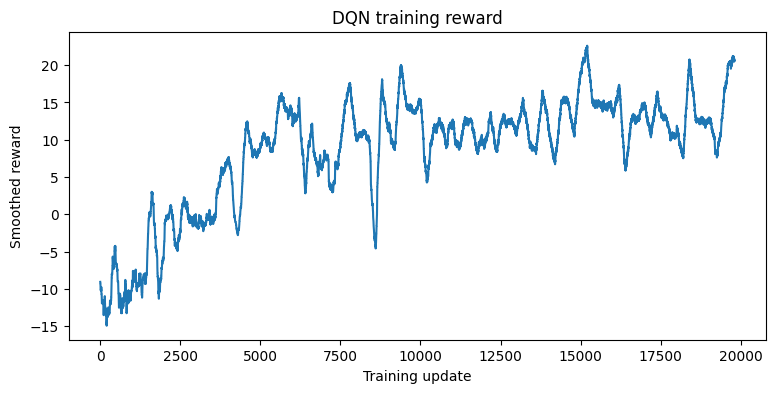

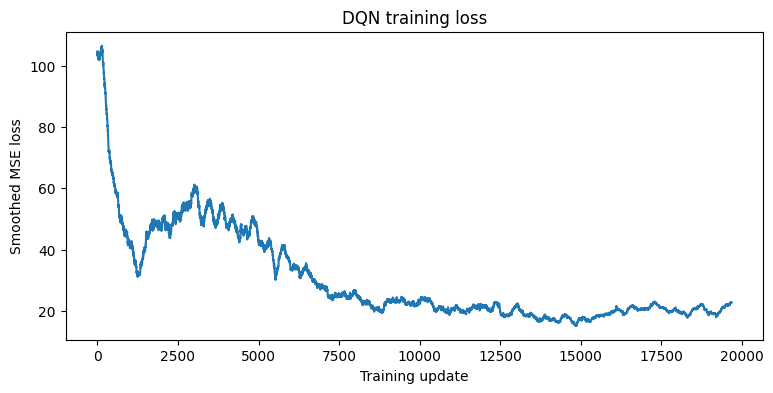

In [12]:
plot_rewards(training_metrics)
plot_losses(training_metrics)

## 13. Greedy evaluation across all possible B locations

Evaluation uses `ε = 0`. B takes each of the 24 cells other than A, and each B location is repeated three times with random sequential agent order.

- **Agent success:** fraction of individual agents completing A→B→A collision-free.
- **Scenario success:** fraction of four-agent scenarios where **all four** complete the cycle collision-free.

In [13]:
evaluation = evaluate_dqn(
    learner,
    evaluation_config,
)

print("Scenarios:", evaluation.scenarios)
print("Agent trials:", evaluation.agent_trials)
print("Agent success rate:", f"{evaluation.agent_success_rate:.2%}")
print("Scenario success rate:", f"{evaluation.scenario_success_rate:.2%}")
print("Evaluation collisions:", evaluation.collisions)

assert evaluation.scenario_success_rate >= 0.75
assert evaluation.collisions == 0

Scenarios: 72
Agent trials: 288
Agent success rate: 94.10%
Scenario success rate: 84.72%
Evaluation collisions: 0


## 14. Performance points and cost scaling

`C = 3` because the solution purchases only the opposite-direction neighbouring-agent sensor.

In [14]:
score = calculate_score(
    evaluation.scenario_success_rate,
    training_metrics.collisions,
    training_config.cost,
)

print("Success points:", score.success_points)
print("Collision points:", score.collision_points)
print("Performance points B:", score.performance_points)
print("Cost C:", score.cost)
print("Scaling factor:", round(score.scale, 3))

Success points: 0
Collision points: 1
Performance points B: 1
Cost C: 3
Scaling factor: 0.67


## 15. One greedy demonstration

The following cell advances one evaluated world for several random-order rounds and plots the resulting grid. Circles carry an item toward B; triangles are returning toward A.

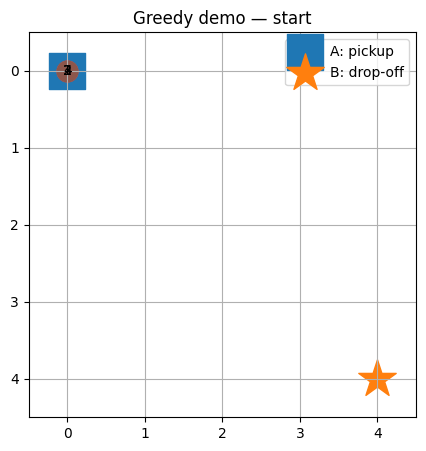

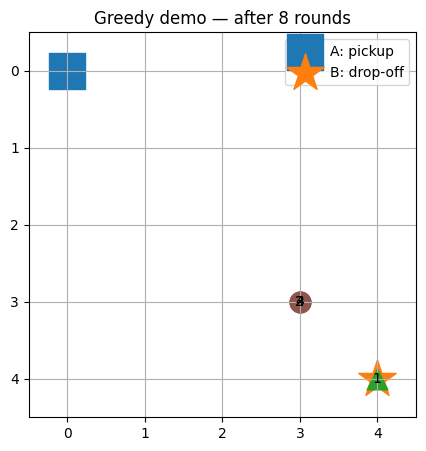

In [15]:
demo = Evaluator(learner, EvaluationConfig(repeats=1, seed=314))
demo.world = create_evaluation_world((4, 4))

plot_world(demo.world, "Greedy demo — start")

for _ in range(8):
    demo.run_round()

plot_world(demo.world, "Greedy demo — after 8 rounds")

## 16. Save machine-readable configuration

In [16]:
config_payload = {
    "learning": asdict(learning_config),
    "training": asdict(training_config),
    "evaluation": asdict(evaluation_config),
}

Path("config.json").write_text(
    json.dumps(config_payload, indent=2),
    encoding="utf-8",
)

print(Path("config.json").read_text(encoding="utf-8"))

{
  "learning": {
    "learning_rate": 0.001,
    "gamma": 0.95,
    "epsilon_start": 1.0,
    "epsilon_min": 0.03,
    "epsilon_decay_fraction": 0.2,
    "replay_capacity": 50000,
    "batch_size": 64,
    "warmup_steps": 512,
    "target_sync_updates": 500,
    "gradient_clip": 10.0,
    "hidden_size": 64
  },
  "training": {
    "agent_steps": 80000,
    "reset_interval_steps": 800,
    "seed": 1,
    "cost": 3
  },
  "evaluation": {
    "max_actions": 25,
    "repeats": 3,
    "seed": 99
  }
}


## What this solution does — and does not do

**It does:**
- train one shared DQN from randomly initialized weights;
- use random sequential agent updates;
- randomize B during training;
- use experience replay and a target network;
- evaluate all 24 possible B cells;
- directly measure the 25-step, collision-free requirement;
- enforce and report the training budgets.
